# CartPole with Gymnasium

This notebook walks through the CartPole-v1 environment from the [Gymnasium](https://gymnasium.farama.org/environments/classic_control/cart_pole/) library, a standard benchmark in reinforcement learning.

The CartPole problem was originally described by Barto, Sutton, and Anderson (1983) in *Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problems*. The goal is simple: balance a pole on a moving cart by pushing the cart left or right.

---

**Sections:**
1. Installation
2. Environment Basics
3. Observation and Action Spaces
4. Running a Random Agent
5. Visualizing a Rollout
6. Vectorized Environments
7. Reward Variants
8. Relation to Salient Networks
9. Training with DQN
10. Parameters and Latent Spaces
11. The Physical Model: How Actions Become Motion
12. Does the Latent Space Encode Physics?

## 1. Installation

First, install Gymnasium and a few supporting libraries for visualization.

In [ ]:
!pip install gymnasium matplotlib numpy --quiet

## 2. Environment Basics

We create the CartPole-v1 environment using `gymnasium.make`. The `render_mode="rgb_array"` option tells the environment to return frames as NumPy arrays, which we can display in the notebook.

In [ ]:
import gymnasium as gym
import numpy as np

env = gym.make("CartPole-v1", render_mode="rgb_array")

# reset() initializes the environment and returns the first observation
observation, info = env.reset(seed=42)

print("Initial observation:", observation)
print()
print("Observation meaning:")
print(f"  Cart Position:        {observation[0]:.4f}")
print(f"  Cart Velocity:        {observation[1]:.4f}")
print(f"  Pole Angle (rad):     {observation[2]:.4f}")
print(f"  Pole Angular Velocity:{observation[3]:.4f}")

Initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]

Observation meaning:
  Cart Position:        0.0274
  Cart Velocity:        -0.0061
  Pole Angle (rad):     0.0359
  Pole Angular Velocity:0.0197


## 3. Observation and Action Spaces

Understanding the spaces tells us what the agent can observe and what actions it can take.

| Index | Observation | Min | Max |
|-------|-------------|-----|-----|
| 0 | Cart Position | -4.8 | 4.8 |
| 1 | Cart Velocity | -Inf | Inf |
| 2 | Pole Angle (radians) | -0.418 | 0.418 |
| 3 | Pole Angular Velocity | -Inf | Inf |

The **action space** has two discrete options:
- `0`: Push cart to the **left**
- `1`: Push cart to the **right**

> Note: The episode terminates early if the cart position leaves (-2.4, 2.4) or the pole angle leaves (-0.2095, 0.2095) radians.

In [ ]:
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)
print()
print("Observation space lower bounds:", env.observation_space.low)
print("Observation space upper bounds:", env.observation_space.high)
print()
# Sample a random action
random_action = env.action_space.sample()
print("Random action sampled:", random_action, "(0=left, 1=right)")

Action space: Discrete(2)
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Observation space lower bounds: [-4.8               -inf -0.41887903        -inf]
Observation space upper bounds: [4.8               inf 0.41887903        inf]

Random action sampled: 1 (0=left, 1=right)


## 4. Running a Random Agent

The simplest possible agent picks a random action at every step. This gives us a baseline to understand the environment loop:

```
reset -> observe -> act -> observe -> act -> ... -> terminated/truncated
```

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, info = env.reset(seed=0)

total_reward = 0
steps = 0

while True:
    action = env.action_space.sample()  # random policy
    observation, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    steps += 1

    if terminated or truncated:
        break

env.close()

print(f"Episode finished after {steps} steps")
print(f"Total reward: {total_reward}")
print()
print("A perfect agent would reach the max of 500 steps.")
print("A random agent typically lasts around 10-25 steps.")

Episode finished after 23 steps
Total reward: 23.0

A perfect agent would reach the max of 500 steps.
A random agent typically lasts around 10-25 steps.


### Custom Starting State Bounds

By default, the environment starts with all observations drawn uniformly from (-0.05, 0.05). You can widen or tighten this range using the `options` parameter on `reset`.

In [ ]:
env = gym.make("CartPole-v1", render_mode="rgb_array")

# Default starting range
obs_default, _ = env.reset(seed=123)
print("Default start (low=-0.05, high=0.05):", obs_default)

# Wider starting range makes the task harder
obs_wide, _ = env.reset(seed=123, options={"low": -0.1, "high": 0.1})
print("Wider start  (low=-0.10, high=0.10):", obs_wide)

env.close()

Default start (low=-0.05, high=0.05): [ 0.01823519 -0.0446179  -0.02796401 -0.03156282]
Wider start  (low=-0.10, high=0.10): [ 0.03647037 -0.0892358  -0.05592803 -0.06312564]


## 5. Visualizing a Rollout

We can capture frames from each step and display them as an animation inline using Matplotlib.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

env = gym.make("CartPole-v1", render_mode="rgb_array")
observation, _ = env.reset(seed=7)

frames = []

for _ in range(100):  # capture up to 100 frames
    frame = env.render()
    frames.append(frame)
    action = env.action_space.sample()
    observation, reward, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break

env.close()

# Animate the frames
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
plt.close()
HTML(ani.to_jshtml())

### Plotting Observations Over Time

It is also useful to track how each observation component evolves during an episode.

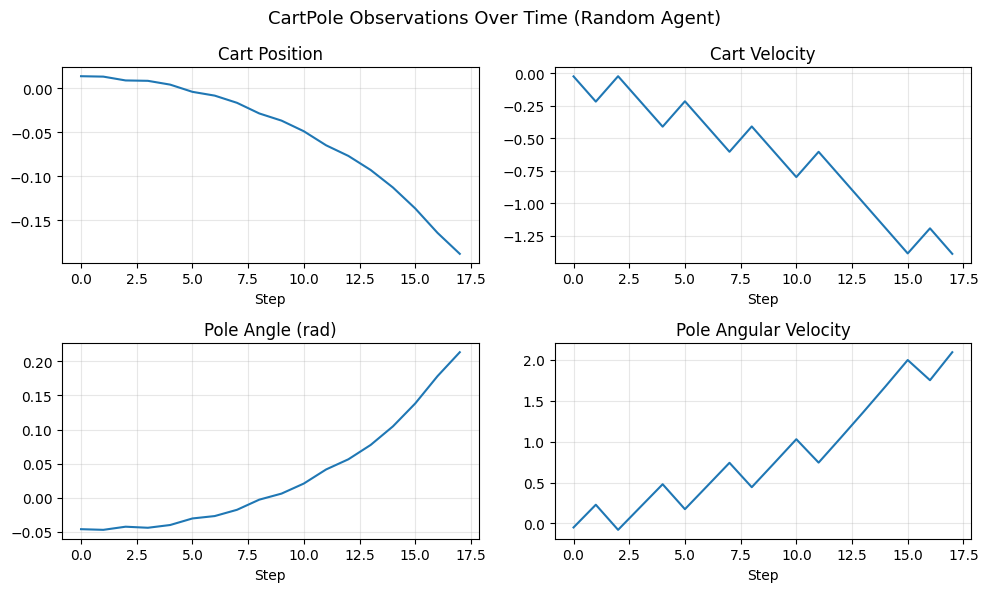

In [ ]:
env = gym.make("CartPole-v1")
observation, _ = env.reset(seed=0)

history = [observation]

while True:
    action = env.action_space.sample()
    observation, reward, terminated, truncated, _ = env.step(action)
    history.append(observation)
    if terminated or truncated:
        break

env.close()

history = np.array(history)
labels = ["Cart Position", "Cart Velocity", "Pole Angle (rad)", "Pole Angular Velocity"]

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
fig.suptitle("CartPole Observations Over Time (Random Agent)", fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.plot(history[:, i])
    ax.set_title(labels[i])
    ax.set_xlabel("Step")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Vectorized Environments

Gymnasium supports running multiple independent environment instances in parallel. This is useful for collecting experience faster during training.

There are two vectorization modes:
- `vector_entry_point`: Uses a native, optimized vector implementation (faster)
- `sync`: Wraps individual environments in a synchronous loop (more flexible)

In [ ]:
# Native vectorized environment (faster)
envs_native = gym.make_vec("CartPole-v1", num_envs=4, vectorization_mode="vector_entry_point")
print("Native vec env:", envs_native)

# Sync vectorized environment (more flexible)
envs_sync = gym.make_vec("CartPole-v1", num_envs=4, vectorization_mode="sync")
print("Sync vec env:  ", envs_sync)

Native vec env: CartPoleVectorEnv(CartPole-v1, num_envs=4)
Sync vec env:   SyncVectorEnv(CartPole-v1, num_envs=4)


In [ ]:
# Run one step across all 4 environments simultaneously
observations, infos = envs_native.reset(seed=0)
print("Observations from all 4 envs (shape):", observations.shape)
print(observations)
print()

# Sample one action per environment
actions = envs_native.action_space.sample()
print("Actions:", actions)

observations, rewards, terminations, truncations, infos = envs_native.step(actions)
print("Rewards after one step:", rewards)

envs_native.close()

Observations from all 4 envs (shape): (4, 4)
[[ 0.01369617  0.03132702  0.0043625   0.03574043]
 [-0.02302133  0.04127556  0.04350724 -0.04664144]
 [-0.04590265  0.01066358  0.03158535  0.02296554]
 [-0.04834723  0.02294966 -0.04972615 -0.03243444]]

Actions: [0 1 0 0]
Rewards after one step: [1. 1. 1. 1.]


## 7. Reward Variants

CartPole-v1 supports two reward formulations:

| Mode | Non-terminal step | Terminal step | Threshold |
|------|-------------------|---------------|-----------|
| Default | +1 | +1 | 500 |
| Sutton-Barto | 0 | -1 | 0 |

The Sutton-Barto variant more closely follows the original paper and can affect how quickly a learning algorithm converges.

In [ ]:
def run_episode(env, seed=0):
    obs, _ = env.reset(seed=seed)
    total = 0
    rewards = []
    while True:
        action = env.action_space.sample()
        obs, reward, terminated, truncated, _ = env.step(action)
        rewards.append(reward)
        total += reward
        if terminated or truncated:
            break
    env.close()
    return rewards, total

# Default reward
env_default = gym.make("CartPole-v1")
rewards_default, total_default = run_episode(env_default, seed=5)

# Sutton-Barto reward
env_sb = gym.make("CartPole-v1", sutton_barto_reward=True)
rewards_sb, total_sb = run_episode(env_sb, seed=5)

print(f"Default reward   -- steps: {len(rewards_default)}, total: {total_default}")
print(f"Sutton-Barto     -- steps: {len(rewards_sb)}, total: {total_sb}")
print()
print("Default rewards (last 5 steps):", rewards_default[-5:])
print("Sutton-Barto rewards (last 5 steps):", rewards_sb[-5:])

Default reward   -- steps: 16, total: 16.0
Sutton-Barto     -- steps: 20, total: -1.0

Default rewards (last 5 steps): [1.0, 1.0, 1.0, 1.0, 1.0]
Sutton-Barto rewards (last 5 steps): [0.0, 0.0, 0.0, 0.0, -1.0]


## 8. Relation to Salient Networks

### What is a Salient Network?

In neuroscience, the **salience network** is a set of brain regions (primarily the anterior insula and anterior cingulate cortex) that detect and orient attention toward stimuli that are behaviorally relevant. It acts as a switching mechanism: deciding what deserves attention and routing processing toward either the default mode network (internal thought) or the executive control network (goal-directed action).

In machine learning and reinforcement learning, **salient** refers to features or signals that are most relevant to decision-making. A salient network, in this context, is a model that learns to identify and prioritize these high-signal features from a noisy observation space.

---

### Why CartPole is a Good Testbed

CartPole provides a four-dimensional observation vector. Not all dimensions carry equal weight for the balancing task at all times:

- **Pole angle** and **pole angular velocity** are the most immediately salient signals. A large angle or rapidly growing angular velocity is the primary precursor to failure.
- **Cart position** and **cart velocity** become salient only when the cart is approaching the track boundary.

A naive policy treats all four inputs equally. A salience-aware policy learns to shift its attention based on which signals are currently most predictive of failure.

---

### Salience in Practice: Attention Weights

One way to operationalize this is with a simple attention mechanism over the observation vector. The cell below demonstrates a minimal example: a learned weighting over the four observation dimensions, where higher weights indicate that the network is treating that feature as more salient.

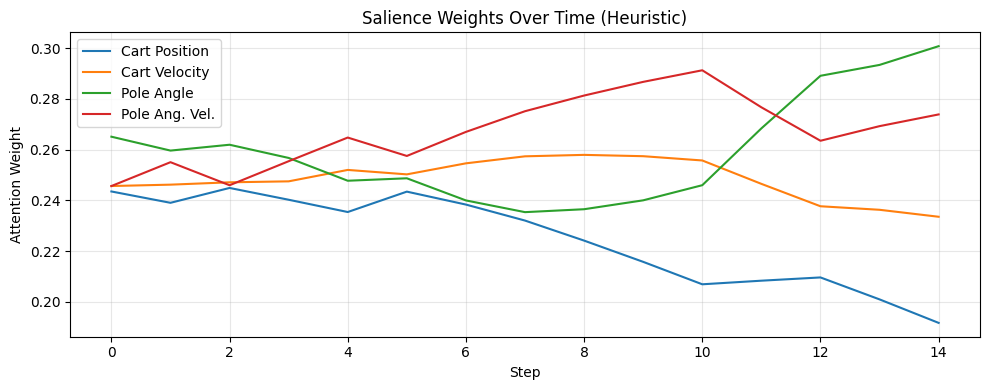

Average salience weights across episode:
  Cart Position         : 0.2250
  Cart Velocity         : 0.2484
  Pole Angle            : 0.2593
  Pole Ang. Vel.        : 0.2673


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def softmax(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

def compute_salience_weights(observation):
    """
    A simple heuristic salience function.

    In a trained network these weights would come from learned parameters.
    Here we use the absolute magnitude of each observation component as a
    proxy for how much that signal 'stands out' relative to its normal range.
    """
    obs_ranges = np.array([4.8, 5.0, 0.418, 5.0])  # approximate max magnitudes
    normalized = np.abs(observation) / obs_ranges
    return softmax(normalized)

# Collect observations from a short episode
env = gym.make("CartPole-v1")
observation, _ = env.reset(seed=1)

obs_history = []
salience_history = []

for _ in range(60):
    weights = compute_salience_weights(observation)
    obs_history.append(observation)
    salience_history.append(weights)
    action = env.action_space.sample()
    observation, _, terminated, truncated, _ = env.step(action)
    if terminated or truncated:
        break

env.close()

salience_history = np.array(salience_history)
labels = ["Cart Position", "Cart Velocity", "Pole Angle", "Pole Ang. Vel."]

fig, ax = plt.subplots(figsize=(10, 4))
for i, label in enumerate(labels):
    ax.plot(salience_history[:, i], label=label)

ax.set_title("Salience Weights Over Time (Heuristic)")
ax.set_xlabel("Step")
ax.set_ylabel("Attention Weight")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Average salience weights across episode:")
for label, weight in zip(labels, salience_history.mean(axis=0)):
    print(f"  {label:<22}: {weight:.4f}")

### Connecting to Reinforcement Learning

In a trained RL agent (such as one using Proximal Policy Optimization or Deep Q-Networks), the network implicitly learns something similar:

- **Reward signal as salience driver**: Because reward is only +1 per step (or -1 at termination in Sutton-Barto mode), the network must learn which features are predictive of *long-term* reward, not just immediate states.
- **Temporal difference error**: The TD error in Q-learning and actor-critic methods functions as a biological-style salience signal. A large TD error means something unexpected happened, which triggers stronger weight updates for features associated with that moment.
- **Sparse, high-stakes termination**: CartPole terminates abruptly when the pole falls. This means the agent must learn to treat growing pole angle and angular velocity as *salient warning signals* well before failure, since there is no intermediate negative reward.

Modern architectures such as **transformer-based policies** and **attention-augmented actor-critics** make this salience mechanism explicit, learning dynamic attention weights over the observation space rather than relying on the network to implicitly encode it in its weights.

CartPole, despite its simplicity, makes these dynamics legible and is a common environment for demonstrating and debugging attention-based policy networks.

## 9. Training with DQN

### Overview

Deep Q-Network (DQN) is a natural fit for CartPole. The action space is discrete (left or right), and the observation space is small enough that a compact neural network can represent the Q-function well.

The core idea: instead of a lookup table mapping (state, action) pairs to expected returns, we train a neural network to approximate the Q-function:

```
Q(s, a; theta)  -->  expected cumulative reward from state s, taking action a
```

At each step, we select the action with the highest Q-value. During training, we update the network using the **Bellman equation**:

```
target = r + gamma * max_a' Q(s', a'; theta_target)
loss   = (Q(s, a; theta) - target)^2
```

Two key stabilization techniques are used:
- **Replay buffer**: stores past transitions and samples random mini-batches, breaking temporal correlations in the training data.
- **Target network**: a periodically updated copy of the Q-network used to compute targets, preventing the network from chasing a moving target.

In [ ]:
!pip install torch --quiet

In [ ]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import deque

import torch
import torch.nn as nn
import torch.optim as optim

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.10.0+cpu
Using device: cpu


### The Q-Network

Our network takes the 4-dimensional observation as input and outputs a Q-value for each of the 2 actions. The hidden layers form the **latent representation** of the state, which we will revisit in Section 10.

In [ ]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)

    def get_hidden(self, x):
        """Return the activation of the second hidden layer (the latent state)."""
        x = torch.relu(self.net[0](x))
        x = torch.relu(self.net[2](x))
        return x


# Quick shape check
net = QNetwork(obs_dim=4, action_dim=2)
dummy = torch.zeros(1, 4)
print("Q-values for dummy input:", net(dummy))
print("Hidden representation shape:", net.get_hidden(dummy).shape)

Q-values for dummy input: tensor([[0.0402, 0.0460]], grad_fn=<AddmmBackward0>)
Hidden representation shape: torch.Size([1, 128])


### Replay Buffer

The replay buffer stores `(state, action, reward, next_state, done)` tuples. During training, we sample random mini-batches from it rather than training on consecutive transitions.

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity=10_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.tensor(np.array(states), dtype=torch.float32),
            torch.tensor(actions, dtype=torch.long),
            torch.tensor(rewards, dtype=torch.float32),
            torch.tensor(np.array(next_states), dtype=torch.float32),
            torch.tensor(dones, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)

print("ReplayBuffer defined.")

ReplayBuffer defined.


### Hyperparameters

These are the key knobs you can turn. We will revisit what several of these mean in the context of latent spaces in Section 10.

In [ ]:
# --- Training hyperparameters ---
EPISODES        = 600     # increased from 400 to give the agent more time to consolidate
BATCH_SIZE      = 128     # increased from 64; pairs well with the larger buffer
GAMMA           = 0.99    # discount factor: how much future rewards are valued
LR              = 1e-3    # learning rate for the Adam optimizer
HIDDEN_DIM      = 128     # width of each hidden layer (determines latent space size)
BUFFER_CAPACITY = 50_000  # increased from 10k; more diverse transitions per mini-batch
TARGET_UPDATE   = 5       # sync target network more frequently (was 10) for mid-training stability
GRAD_CLIP       = 10.0    # max gradient norm; prevents large updates destabilizing a good policy

# --- Epsilon-greedy exploration ---
EPS_START = 1.0    # start fully random
EPS_END   = 0.01   # settle at 1% random actions
EPS_DECAY = 0.995  # multiplicative decay per episode

print("Hyperparameters set.")

Hyperparameters set.


### Training Loop

This cell runs the full DQN training loop. On a Colab CPU it typically completes in 3-5 minutes. Three stabilization measures are layered in beyond a basic DQN:

- A larger replay buffer (50k) and batch size (128) reduce correlation between training samples
- The target network syncs every 5 episodes rather than 10, keeping the bootstrap target fresher
- Gradient clipping (norm <= 10) prevents occasional large updates from knocking the agent off a policy it has already learned

You should see episode rewards climbing from around 10-20 and consistently reaching 400-500 by the end of training.

In [ ]:
env = gym.make("CartPole-v1")
obs_dim    = env.observation_space.shape[0]  # 4
action_dim = env.action_space.n              # 2

q_net      = QNetwork(obs_dim, action_dim, HIDDEN_DIM).to(device)
target_net = QNetwork(obs_dim, action_dim, HIDDEN_DIM).to(device)
target_net.load_state_dict(q_net.state_dict())
target_net.eval()

optimizer = optim.Adam(q_net.parameters(), lr=LR)
buffer    = ReplayBuffer(BUFFER_CAPACITY)

epsilon      = EPS_START
episode_rewards = []

for episode in range(EPISODES):
    state, _ = env.reset()
    total_reward = 0

    while True:
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                q_vals = q_net(torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device))
                action = q_vals.argmax().item()

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buffer.push(state, action, reward, next_state, float(done))
        state = next_state
        total_reward += reward

        # Train when we have enough samples
        if len(buffer) >= BATCH_SIZE:
            states_b, actions_b, rewards_b, next_states_b, dones_b = buffer.sample(BATCH_SIZE)
            states_b      = states_b.to(device)
            actions_b     = actions_b.to(device)
            rewards_b     = rewards_b.to(device)
            next_states_b = next_states_b.to(device)
            dones_b       = dones_b.to(device)

            # Current Q-values
            q_values = q_net(states_b).gather(1, actions_b.unsqueeze(1)).squeeze(1)

            # Bellman target
            with torch.no_grad():
                max_next_q = target_net(next_states_b).max(1).values
                targets = rewards_b + GAMMA * max_next_q * (1 - dones_b)

            loss = nn.functional.mse_loss(q_values, targets)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(q_net.parameters(), GRAD_CLIP)  # gradient clipping
            optimizer.step()

        if done:
            break

    episode_rewards.append(total_reward)
    epsilon = max(EPS_END, epsilon * EPS_DECAY)

    if (episode + 1) % TARGET_UPDATE == 0:
        target_net.load_state_dict(q_net.state_dict())

    if (episode + 1) % 50 == 0:
        avg = np.mean(episode_rewards[-50:])
        print(f"Episode {episode+1:>4} | Avg reward (last 50): {avg:.1f} | Epsilon: {epsilon:.3f}")

env.close()
print("\nTraining complete.")

Episode   50 | Avg reward (last 50): 26.1 | Epsilon: 0.778
Episode  100 | Avg reward (last 50): 45.7 | Epsilon: 0.606
Episode  150 | Avg reward (last 50): 66.0 | Epsilon: 0.471
Episode  200 | Avg reward (last 50): 64.3 | Epsilon: 0.367
Episode  250 | Avg reward (last 50): 68.0 | Epsilon: 0.286
Episode  300 | Avg reward (last 50): 179.7 | Epsilon: 0.222
Episode  350 | Avg reward (last 50): 240.2 | Epsilon: 0.173
Episode  400 | Avg reward (last 50): 306.5 | Epsilon: 0.135
Episode  450 | Avg reward (last 50): 313.3 | Epsilon: 0.105
Episode  500 | Avg reward (last 50): 301.8 | Epsilon: 0.082
Episode  550 | Avg reward (last 50): 378.0 | Epsilon: 0.063
Episode  600 | Avg reward (last 50): 326.2 | Epsilon: 0.049

Training complete.


### Reward Curve

A smoothed reward curve shows how performance improves over training. The raw episode rewards are noisy due to epsilon-greedy exploration, so we overlay a rolling average.

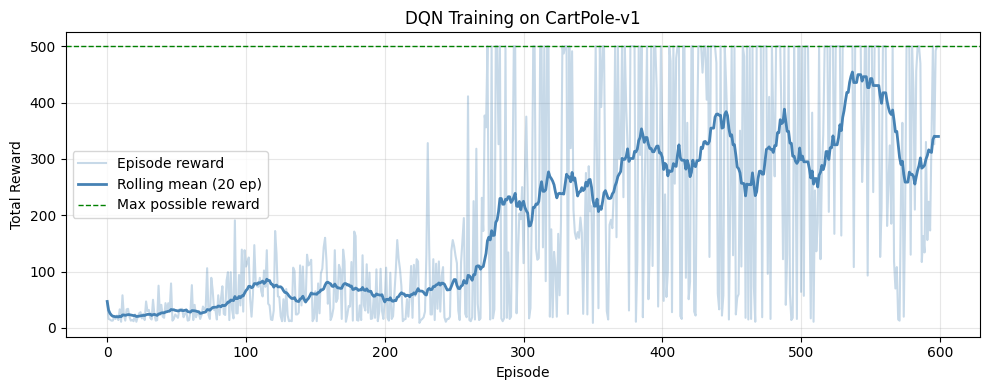

In [ ]:
def rolling_mean(data, window=20):
    return [np.mean(data[max(0, i - window):i + 1]) for i in range(len(data))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(episode_rewards, alpha=0.3, color="steelblue", label="Episode reward")
ax.plot(rolling_mean(episode_rewards), color="steelblue", linewidth=2, label="Rolling mean (20 ep)")
ax.axhline(500, color="green", linestyle="--", linewidth=1, label="Max possible reward")
ax.set_title("DQN Training on CartPole-v1")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Evaluating the Trained Agent

With epsilon set to zero, the agent acts greedily. We run several evaluation episodes and compare against the random baseline from Section 4.

In [ ]:
def evaluate_agent(q_net, n_episodes=10, seed=99):
    env = gym.make("CartPole-v1")
    rewards = []
    for i in range(n_episodes):
        state, _ = env.reset(seed=seed + i)
        total = 0
        while True:
            with torch.no_grad():
                q_vals = q_net(torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device))
                action = q_vals.argmax().item()
            state, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break
        rewards.append(total)
    env.close()
    return rewards

eval_rewards = evaluate_agent(q_net, n_episodes=10)
print("Trained agent evaluation rewards:", eval_rewards)
print(f"Mean: {np.mean(eval_rewards):.1f}  |  Min: {np.min(eval_rewards):.0f}  |  Max: {np.max(eval_rewards):.0f}")
print()
print("Recall: a random agent typically scores 10-25 per episode.")

Trained agent evaluation rewards: [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Mean: 500.0  |  Min: 500  |  Max: 500

Recall: a random agent typically scores 10-25 per episode.


## 10. Parameters and Latent Spaces

### What Are the Parameters?

Every connection in the Q-network has a learned weight. These weights are the **parameters** of the model, updated by gradient descent during training. In our network:

```
Layer 1:  4   inputs  -> 128 hidden units  =   512 weights +  128 biases
Layer 2:  128 hidden  -> 128 hidden units  = 16384 weights +  128 biases
Layer 3:  128 hidden  ->   2 outputs       =   256 weights +    2 biases
```

In total, around 17,000 parameters encode everything the agent has learned about how to balance the pole. The parameters themselves are not interpretable directly, but the **activations** they produce are.

In [ ]:
total_params = sum(p.numel() for p in q_net.parameters())
print(f"Total trainable parameters: {total_params:,}")
print()
for name, param in q_net.named_parameters():
    print(f"  {name:<20} shape: {tuple(param.shape)}  |  count: {param.numel():,}")

Total trainable parameters: 17,410

  net.0.weight         shape: (128, 4)  |  count: 512
  net.0.bias           shape: (128,)  |  count: 128
  net.2.weight         shape: (128, 128)  |  count: 16,384
  net.2.bias           shape: (128,)  |  count: 128
  net.4.weight         shape: (2, 128)  |  count: 256
  net.4.bias           shape: (2,)  |  count: 2


### What Is the Latent Space?

The **latent space** is the internal representation produced by the hidden layers. When a raw observation (4 numbers) passes through the first two layers of the network, it is transformed into a 128-dimensional vector. This vector is the latent representation of that state.

This connects directly to the salient networks discussion in Section 8:

- In a biological salience network, the brain does not act on raw sensory input. It compresses, filters, and recodes it into an internal representation that highlights what matters.
- The hidden layers of the Q-network do the same thing. The network is not trained explicitly to produce a meaningful latent space, but one emerges because it is useful for predicting Q-values accurately.
- Features that are salient for survival (pole angle, angular velocity) should be more strongly encoded in the latent space than features that are less frequently decisive (cart position).

We can test this by collecting latent representations across many states and projecting them into 2D using PCA, then coloring them by pole angle.

In [ ]:
from sklearn.decomposition import PCA

# Collect observations and their latent representations
env = gym.make("CartPole-v1")
all_obs    = []
all_latent = []

q_net.eval()
for episode in range(30):
    state, _ = env.reset(seed=episode)
    while True:
        obs_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            latent = q_net.get_hidden(obs_tensor).squeeze(0).cpu().numpy()
        all_obs.append(state)
        all_latent.append(latent)
        with torch.no_grad():
            action = q_net(obs_tensor).argmax().item()
        state, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break

env.close()

all_obs    = np.array(all_obs)
all_latent = np.array(all_latent)

print(f"Collected {len(all_obs)} state-latent pairs across 30 episodes.")
print(f"Latent array shape: {all_latent.shape}")

Collected 15000 state-latent pairs across 30 episodes.
Latent array shape: (15000, 128)


### Visualizing the Latent Space with PCA

We project the 128-dimensional latent vectors down to 2D. If the latent space has learned a meaningful structure, states with similar physical properties should cluster together.

Variance explained by PC1: 83.30%
Variance explained by PC2: 9.64%


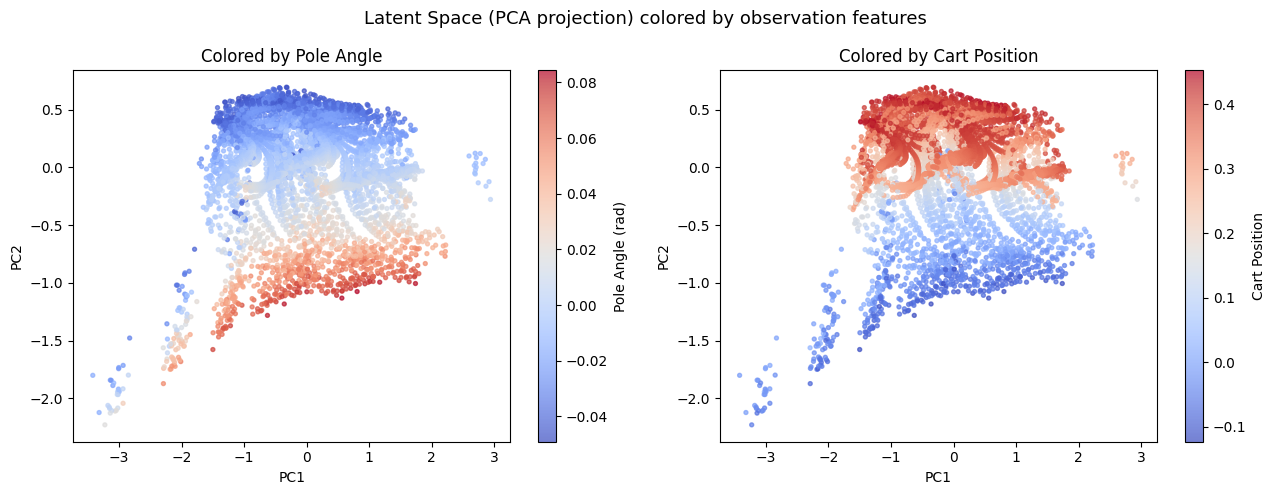

In [ ]:
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(all_latent)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Latent Space (PCA projection) colored by observation features", fontsize=13)

# Color by pole angle
sc1 = axes[0].scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=all_obs[:, 2], cmap="coolwarm", s=8, alpha=0.7)
axes[0].set_title("Colored by Pole Angle")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="Pole Angle (rad)")

# Color by cart position
sc2 = axes[1].scatter(latent_2d[:, 0], latent_2d[:, 1],
                      c=all_obs[:, 0], cmap="coolwarm", s=8, alpha=0.7)
axes[1].set_title("Colored by Cart Position")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="Cart Position")

plt.tight_layout()
plt.show()

### Interpreting the Plot

A few things to look for:

- **Smooth color gradients in the pole angle plot** suggest the latent space has organized itself around pole angle, meaning the network treats this as a primary feature. This is the expected salient signal.
- **Less structured coloring in the cart position plot** would confirm that the latent space encodes cart position less prominently, consistent with it being a secondary, context-dependent signal.
- **The proportion of variance explained by PC1 and PC2** tells you how much of the latent structure is captured in 2D. A high combined variance (e.g., >60%) suggests the latent space is relatively low-dimensional despite being 128-wide, which is common in simple environments.

This is the same phenomenon described in Section 8: the network has implicitly learned a salience ordering, even though it was never explicitly told which features matter most.

### Q-Values as a Function of Pole Angle

As a final check, we can verify that the network's output is sensitive to pole angle by sweeping it across its valid range while holding other observations fixed.

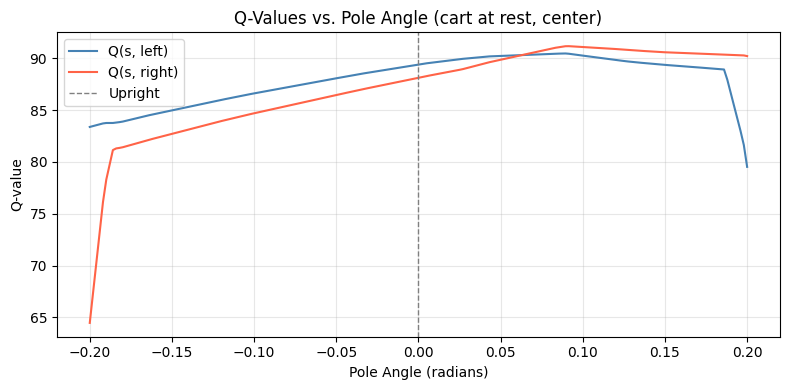

When the pole tilts right (positive angle), the agent should prefer pushing right to correct it.
When the pole tilts left (negative angle), the agent should prefer pushing left.


In [ ]:
angles = np.linspace(-0.2, 0.2, 200)
q_left  = []
q_right = []

q_net.eval()
for angle in angles:
    obs = torch.tensor([[0.0, 0.0, angle, 0.0]], dtype=torch.float32).to(device)
    with torch.no_grad():
        q_vals = q_net(obs).squeeze().cpu().numpy()
    q_left.append(q_vals[0])
    q_right.append(q_vals[1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(angles, q_left,  label="Q(s, left)",  color="steelblue")
ax.plot(angles, q_right, label="Q(s, right)", color="tomato")
ax.axvline(0, color="gray", linestyle="--", linewidth=1, label="Upright")
ax.set_title("Q-Values vs. Pole Angle (cart at rest, center)")
ax.set_xlabel("Pole Angle (radians)")
ax.set_ylabel("Q-value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("When the pole tilts right (positive angle), the agent should prefer pushing right to correct it.")
print("When the pole tilts left (negative angle), the agent should prefer pushing left.")

## 11. The Physical Model: How Actions Become Motion


### Where the physics lives

Gymnasium's CartPole environment is implemented in `gymnasium/envs/classic_control/cartpole.py`. The relevant physical constants are defined at initialization:

```python
self.gravity     = 9.8   # m/s^2
self.masscart    = 1.0   # kg
self.masspole    = 0.1   # kg
self.length      = 0.5   # meters, half the pole length
self.force_mag   = 10.0  # Newtons, magnitude of the push
self.tau         = 0.02  # seconds, the simulation timestep
```

When `env.step(action)` is called, the first thing the environment does is convert the discrete action to a signed force:

```python
force = self.force_mag if action == 1 else -self.force_mag
# action 1 (right) -> +10 N
# action 0 (left)  -> -10 N
```

That force is then fed into the **equations of motion for an inverted pendulum on a cart**, derived from Lagrangian mechanics:

```python
total_mass   = self.masscart + self.masspole          # 1.1 kg
polemass_length = self.masspole * self.length         # 0.05 kg*m

# Current state
x, x_dot, theta, theta_dot = state

costheta = cos(theta)
sintheta = sin(theta)

# Intermediate term from the equations of motion
temp = (force + polemass_length * theta_dot**2 * sintheta) / total_mass

# Angular acceleration of the pole
thetaacc = (self.gravity * sintheta - costheta * temp) / (
    self.length * (4.0/3.0 - self.masspole * costheta**2 / total_mass)
)

# Linear acceleration of the cart
xacc = temp - polemass_length * thetaacc * costheta / total_mass
```

Finally the state is integrated forward by one timestep using Euler integration:

```python
x         = x         + self.tau * x_dot
x_dot     = x_dot     + self.tau * xacc
theta     = theta     + self.tau * theta_dot
theta_dot = theta_dot + self.tau * thetaacc
```

### What this means physically

The key insight is that the force does **not** directly move the cart by a fixed amount. The cart acceleration depends on the **current pole angle** through the `costheta` and `sintheta` terms. When the pole is leaning to one side, gravity pulls it further in that direction, and the cart must overcome both its own inertia and the rotational inertia of the pole.

This is why the Gymnasium documentation notes: *'The velocity that is reduced or increased by the applied force is not fixed and it depends on the angle the pole is pointing. The center of gravity of the pole varies the amount of energy needed to move the cart underneath it.'*

The cell below reconstructs these equations in Python so you can inspect them directly.

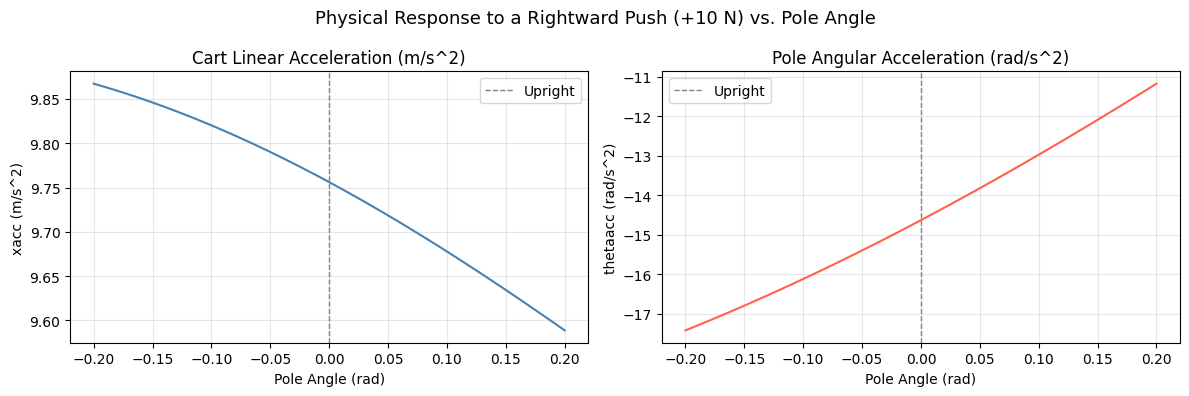

Notice: cart acceleration is NOT constant across pole angles.
The same force produces different motion depending on where the pole is pointing.
At theta=0.0 rad: xacc = 9.755 m/s^2
At theta=0.2 rad: xacc = 9.589 m/s^2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants from cartpole.py
GRAVITY       = 9.8
MASS_CART     = 1.0
MASS_POLE     = 0.1
LENGTH        = 0.5   # half-pole length
FORCE_MAG     = 10.0
TAU           = 0.02  # seconds per step

TOTAL_MASS      = MASS_CART + MASS_POLE
POLEMASS_LENGTH = MASS_POLE * LENGTH


def cartpole_step(state, action):
    """
    Reproduce the CartPole physics from gymnasium/envs/classic_control/cartpole.py.

    Parameters
    ----------
    state  : (x, x_dot, theta, theta_dot)
    action : 0 (left) or 1 (right)

    Returns
    -------
    next_state : (x, x_dot, theta, theta_dot)
    xacc       : cart linear acceleration (m/s^2)
    thetaacc   : pole angular acceleration (rad/s^2)
    """
    x, x_dot, theta, theta_dot = state
    force = FORCE_MAG if action == 1 else -FORCE_MAG

    costheta = np.cos(theta)
    sintheta = np.sin(theta)

    temp     = (force + POLEMASS_LENGTH * theta_dot**2 * sintheta) / TOTAL_MASS
    thetaacc = (GRAVITY * sintheta - costheta * temp) / (
        LENGTH * (4.0 / 3.0 - MASS_POLE * costheta**2 / TOTAL_MASS)
    )
    xacc = temp - POLEMASS_LENGTH * thetaacc * costheta / TOTAL_MASS

    # Euler integration
    x         = x         + TAU * x_dot
    x_dot     = x_dot     + TAU * xacc
    theta     = theta     + TAU * theta_dot
    theta_dot = theta_dot + TAU * thetaacc

    return (x, x_dot, theta, theta_dot), xacc, thetaacc


# Show how cart acceleration varies with pole angle for a fixed rightward push
thetas    = np.linspace(-0.2, 0.2, 200)
xaccs     = []
thetaaccs = []

for theta in thetas:
    state = (0.0, 0.0, theta, 0.0)  # cart centered, at rest
    _, xacc, thetaacc = cartpole_step(state, action=1)  # push right
    xaccs.append(xacc)
    thetaaccs.append(thetaacc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Physical Response to a Rightward Push (+10 N) vs. Pole Angle", fontsize=13)

axes[0].plot(thetas, xaccs, color="steelblue")
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1, label="Upright")
axes[0].set_title("Cart Linear Acceleration (m/s^2)")
axes[0].set_xlabel("Pole Angle (rad)")
axes[0].set_ylabel("xacc (m/s^2)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thetas, thetaaccs, color="tomato")
axes[1].axvline(0, color="gray", linestyle="--", linewidth=1, label="Upright")
axes[1].set_title("Pole Angular Acceleration (rad/s^2)")
axes[1].set_xlabel("Pole Angle (rad)")
axes[1].set_ylabel("thetaacc (rad/s^2)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice: cart acceleration is NOT constant across pole angles.")
print("The same force produces different motion depending on where the pole is pointing.")
print(f"At theta=0.0 rad: xacc = {xaccs[100]:.3f} m/s^2")
print(f"At theta=0.2 rad: xacc = {xaccs[-1]:.3f} m/s^2")

In [ ]:
# Inspect the physical parameters directly from the live environment
import gymnasium as gym

env = gym.make("CartPole-v1")
env.reset()

print("Physical constants stored in the CartPole environment:")
print(f"  gravity:    {env.unwrapped.gravity} m/s^2")
print(f"  masscart:   {env.unwrapped.masscart} kg")
print(f"  masspole:   {env.unwrapped.masspole} kg")
print(f"  length:     {env.unwrapped.length} m  (half-pole length)")
print(f"  force_mag:  {env.unwrapped.force_mag} N")
print(f"  tau:        {env.unwrapped.tau} s  (timestep)")
print()
print("Derived quantities:")
print(f"  total_mass:      {env.unwrapped.total_mass} kg")
print(f"  polemass_length: {env.unwrapped.polemass_length} kg*m")

env.close()

Physical constants stored in the CartPole environment:
  gravity:    9.8 m/s^2
  masscart:   1.0 kg
  masspole:   0.1 kg
  length:     0.5 m  (half-pole length)
  force_mag:  10.0 N
  tau:        0.02 s  (timestep)

Derived quantities:
  total_mass:      1.1 kg
  polemass_length: 0.05 kg*m


## 12. Does the Latent Space Encode Physics?


### The question restated

The DQN was trained only on the four observation variables: cart position, cart velocity, pole angle, and pole angular velocity. It was never told the pole mass, cart mass, gravity, force magnitude, or pole length.

Yet the physical equations in Section 11 show that the *dynamics* of the system (how fast things accelerate given a force) are entirely determined by those constants. The question is: did the network have to implicitly learn those dynamics in order to predict Q-values accurately? And if so, is that implicit knowledge recoverable from the latent space?

### Why the answer is almost certainly yes

To predict `Q(s, a)` accurately, the network must learn to anticipate how the state will evolve after taking action `a`. That requires modeling, at least implicitly, the relationship:

```
next_state = f(state, action, physical_constants)
```

The physical constants are fixed across all training episodes. From the network's perspective, they are never visible inputs, but they *are* baked into every transition it ever trains on. The network cannot learn to predict future states correctly without learning the numerical consequences of those constants, even if it has no explicit representation of them.

This is a form of **implicit system identification**: the network identifies the dynamics of the system from observed transitions rather than from explicit parameter labels.

### How to probe this

We cannot read the physical constants directly out of the network weights. What we can do is test whether the latent space is *sensitive* to information that only matters because of the physical constants.

The `thetaacc` (pole angular acceleration) from Section 11 is a nonlinear function of both the current pole angle and the physical constants. If we compute the true `thetaacc` for each state in our latent dataset and check whether it correlates with the latent representation, that is evidence the latent space has encoded the dynamics, not just the raw observations.

In [ ]:
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reuse the latent vectors collected in Section 10.
# If you are running this section independently, re-run the latent collection
# cell in Section 10 first to populate all_obs and all_latent.

# Compute the true physical quantities for each observed state
# using the equations from Section 11.

def compute_physics(obs_array, action=1):
    """
    Given an array of observations (N, 4), compute derived physical quantities
    that depend on the environment's internal constants.
    """
    x      = obs_array[:, 0]
    x_dot  = obs_array[:, 1]
    theta  = obs_array[:, 2]
    th_dot = obs_array[:, 3]

    force    = FORCE_MAG if action == 1 else -FORCE_MAG
    costh    = np.cos(theta)
    sinth    = np.sin(theta)

    temp     = (force + POLEMASS_LENGTH * th_dot**2 * sinth) / TOTAL_MASS
    thetaacc = (GRAVITY * sinth - costh * temp) / (
        LENGTH * (4.0 / 3.0 - MASS_POLE * costh**2 / TOTAL_MASS)
    )
    xacc     = temp - POLEMASS_LENGTH * thetaacc * costh / TOTAL_MASS

    return thetaacc, xacc


thetaacc_true, xacc_true = compute_physics(all_obs)

print(f"Computed physical quantities for {len(all_obs)} states.")
print(f"thetaacc range: [{thetaacc_true.min():.3f}, {thetaacc_true.max():.3f}] rad/s^2")
print(f"xacc range:     [{xacc_true.min():.3f}, {xacc_true.max():.3f}] m/s^2")

Computed physical quantities for 15000 states.
thetaacc range: [-15.388, -13.246] rad/s^2
xacc range:     [9.691, 9.789] m/s^2


In [ ]:
# Test 1: Can the raw observations predict the physical quantities?
# (They should, since thetaacc is a deterministic function of the observations.)
reg_obs = LinearRegression().fit(all_obs, thetaacc_true)
r2_obs  = r2_score(thetaacc_true, reg_obs.predict(all_obs))

# Test 2: Can the latent representation predict the physical quantities?
# A high R^2 here means the latent space has preserved the physically
# relevant structure from the observations.
reg_lat = LinearRegression().fit(all_latent, thetaacc_true)
r2_lat  = r2_score(thetaacc_true, reg_lat.predict(all_latent))

# Test 3: Can the PCA projection (2D) predict the physical quantities?
# This shows how much of the physics survives the dimensionality reduction.
pca     = PCA(n_components=2)
lat_2d  = pca.fit_transform(all_latent)
reg_pca = LinearRegression().fit(lat_2d, thetaacc_true)
r2_pca  = r2_score(thetaacc_true, reg_pca.predict(lat_2d))

print("Linear regression R^2 for predicting pole angular acceleration (thetaacc):")
print(f"  From raw observations (4D):  {r2_obs:.4f}")
print(f"  From latent space (128D):    {r2_lat:.4f}")
print(f"  From PCA projection (2D):    {r2_pca:.4f}")
print()
print("Interpretation:")
print("  - Raw obs R^2 is a ceiling: the observations fully determine thetaacc.")
print("  - Latent R^2 near the ceiling means the latent space preserved the dynamics.")
print("  - PCA R^2 shows how much survives compression to 2D.")

Linear regression R^2 for predicting pole angular acceleration (thetaacc):
  From raw observations (4D):  0.9996
  From latent space (128D):    0.9998
  From PCA projection (2D):    0.7376

Interpretation:
  - Raw obs R^2 is a ceiling: the observations fully determine thetaacc.
  - Latent R^2 near the ceiling means the latent space preserved the dynamics.
  - PCA R^2 shows how much survives compression to 2D.


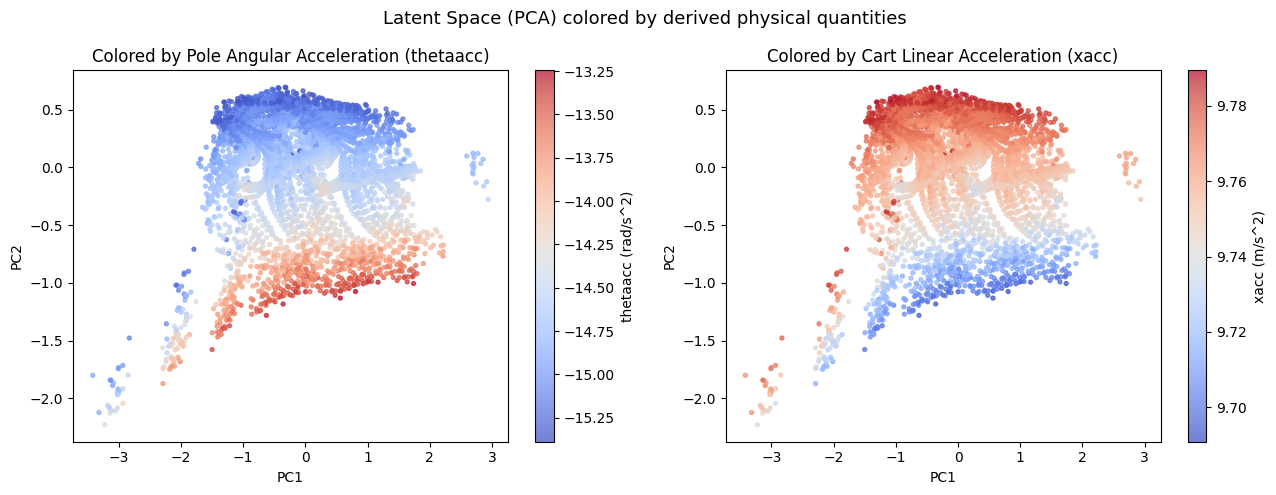

If the latent space shows smooth color gradients for thetaacc and xacc,
it means the network has organized its internal representation around
the physical consequences of actions, not just the raw observations.


In [ ]:
# Visualize the latent space colored by the physical quantities
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Latent Space (PCA) colored by derived physical quantities", fontsize=13)

sc1 = axes[0].scatter(lat_2d[:, 0], lat_2d[:, 1],
                      c=thetaacc_true, cmap="coolwarm", s=8, alpha=0.7)
axes[0].set_title("Colored by Pole Angular Acceleration (thetaacc)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc1, ax=axes[0], label="thetaacc (rad/s^2)")

sc2 = axes[1].scatter(lat_2d[:, 0], lat_2d[:, 1],
                      c=xacc_true, cmap="coolwarm", s=8, alpha=0.7)
axes[1].set_title("Colored by Cart Linear Acceleration (xacc)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(sc2, ax=axes[1], label="xacc (m/s^2)")

plt.tight_layout()
plt.show()

print("If the latent space shows smooth color gradients for thetaacc and xacc,")
print("it means the network has organized its internal representation around")
print("the physical consequences of actions, not just the raw observations.")

### What this tells us about the architecture

The regression and visualization above test a specific claim: that a network trained only on raw state observations has implicitly encoded the Newtonian dynamics of the system in its latent space.

If the latent R^2 is close to the raw observation R^2, the conclusion is that **the latent space is a nearly lossless encoder of the physically relevant information**. The network did not discard the dynamics in order to represent the state; it preserved them, because predicting future Q-values requires predicting future states, which requires the dynamics.

### Could we make this explicit?

The current architecture treats the physical parameters (mass, length, gravity) as invisible constants. Every transition in the replay buffer implicitly reflects them, but they are never named.

An architecture that makes this explicit would:

1. Accept the physical parameters as additional inputs alongside the observation
2. Learn a policy that generalizes across different physical configurations
3. Potentially output a continuous force estimate rather than a discrete left/right action

This is closely related to the field of **model-based reinforcement learning** and **domain randomization**, where an agent is trained across many different physical configurations so that it learns a policy robust to variation in the underlying dynamics. The latent space in such a network would need to explicitly encode which physical regime it is currently operating in, rather than having that baked in as a constant.

---

This Colab was created by Benjamin Williams, benjaminwilliams@umsystem.edu, last edited on 04/13/2026.

---



